# Brain Tumor Classifier
ResNet18-based classifier with Grad-CAM visualization. Covers preprocessing, training, evaluation, and a Gradio app.

## 1. Imports

In [1]:
import tqdm as notebook_tqdm
import os
import shutil

import numpy as np
import cv2
import splitfolders
import pandas as pd

import random
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import transforms, datasets
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.metrics import accuracy_score, confusion_matrix

from PIL import Image, ImageFilter

import gradio as gr
import kagglehub

/opt/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Configuration

In [2]:
# Download dataset from Kaggle
INPUT_PATH = kagglehub.dataset_download("ishans24/brain-tumor-dataset")
print("Path to dataset files:", INPUT_PATH)

BASE_PATH  = os.getcwd()
SPLIT_PATH = os.path.join(BASE_PATH, "dataset_split")
MODEL_PATH = os.path.join(BASE_PATH, "models", "tumor_classifier.pth")

CLASS_NAMES = ["glioma", "meningioma", "no_tumor", "pituitary"]
NUM_CLASSES = len(CLASS_NAMES)

RATIOS     = (0.7, 0.2, 0.1)
SEED       = 1337
BATCH_SIZE = 32
NUM_EPOCHS = 20
LR         = 0.001

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

100%|██████████| 862M/862M [00:27<00:00, 32.5MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ishans24/brain-tumor-dataset/versions/1
Using device: cuda


## 3. Transforms

In [3]:
def get_train_transform():
    return transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.3, contrast=0.3),
        transforms.ToTensor(),
        transforms.RandomErasing(p=0.5),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

def get_eval_transform():
    return transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

def get_display_transform():
    return transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.Resize(256),
        transforms.CenterCrop(224)
    ])

## 4. Preprocessing — Dataset Split

In [4]:
def prepare_output_directory(output_path):
    if os.path.exists(output_path):
        print("Output directory already exists. Clearing it.")
        shutil.rmtree(output_path)
    os.makedirs(output_path)
    print("Output directory created successfully.")

def split_dataset(input_path, output_path, ratios, seed):
    splitfolders.ratio(input_path, output=output_path, seed=seed, ratio=ratios)
    print("Dataset split into train / val / test.")

def preprocessing(ratios=RATIOS, seed=SEED):
    prepare_output_directory(SPLIT_PATH)
    split_dataset(INPUT_PATH, SPLIT_PATH, ratios, seed)

# Run preprocessing
preprocessing()

Output directory already exists. Clearing it.
Output directory created successfully.


Copying files: 10560 files [00:01, 5884.19 files/s]

Dataset split into train / val / test.


## 5. EDA — Exploratory Data Analysis

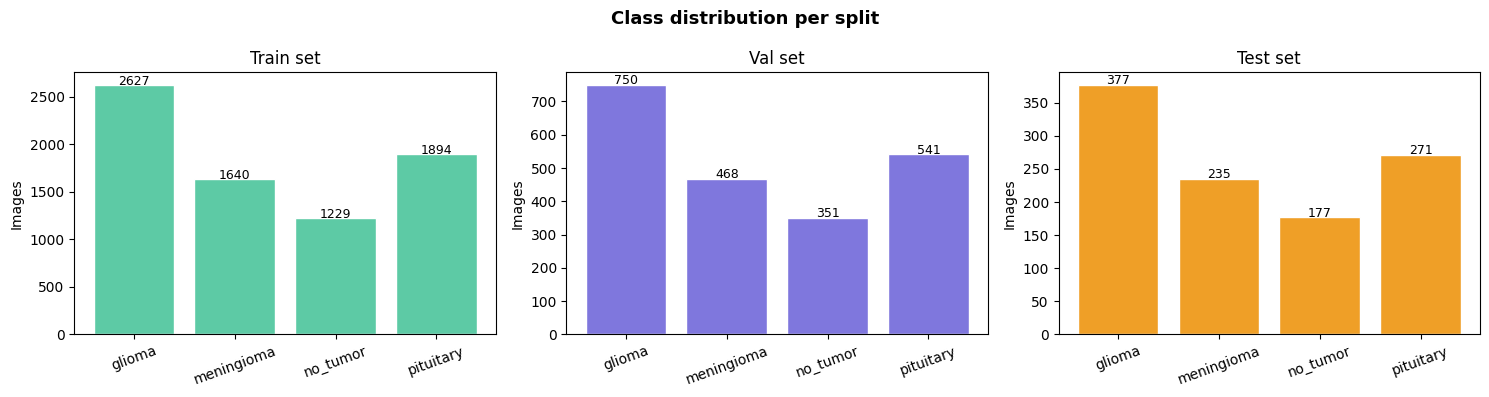

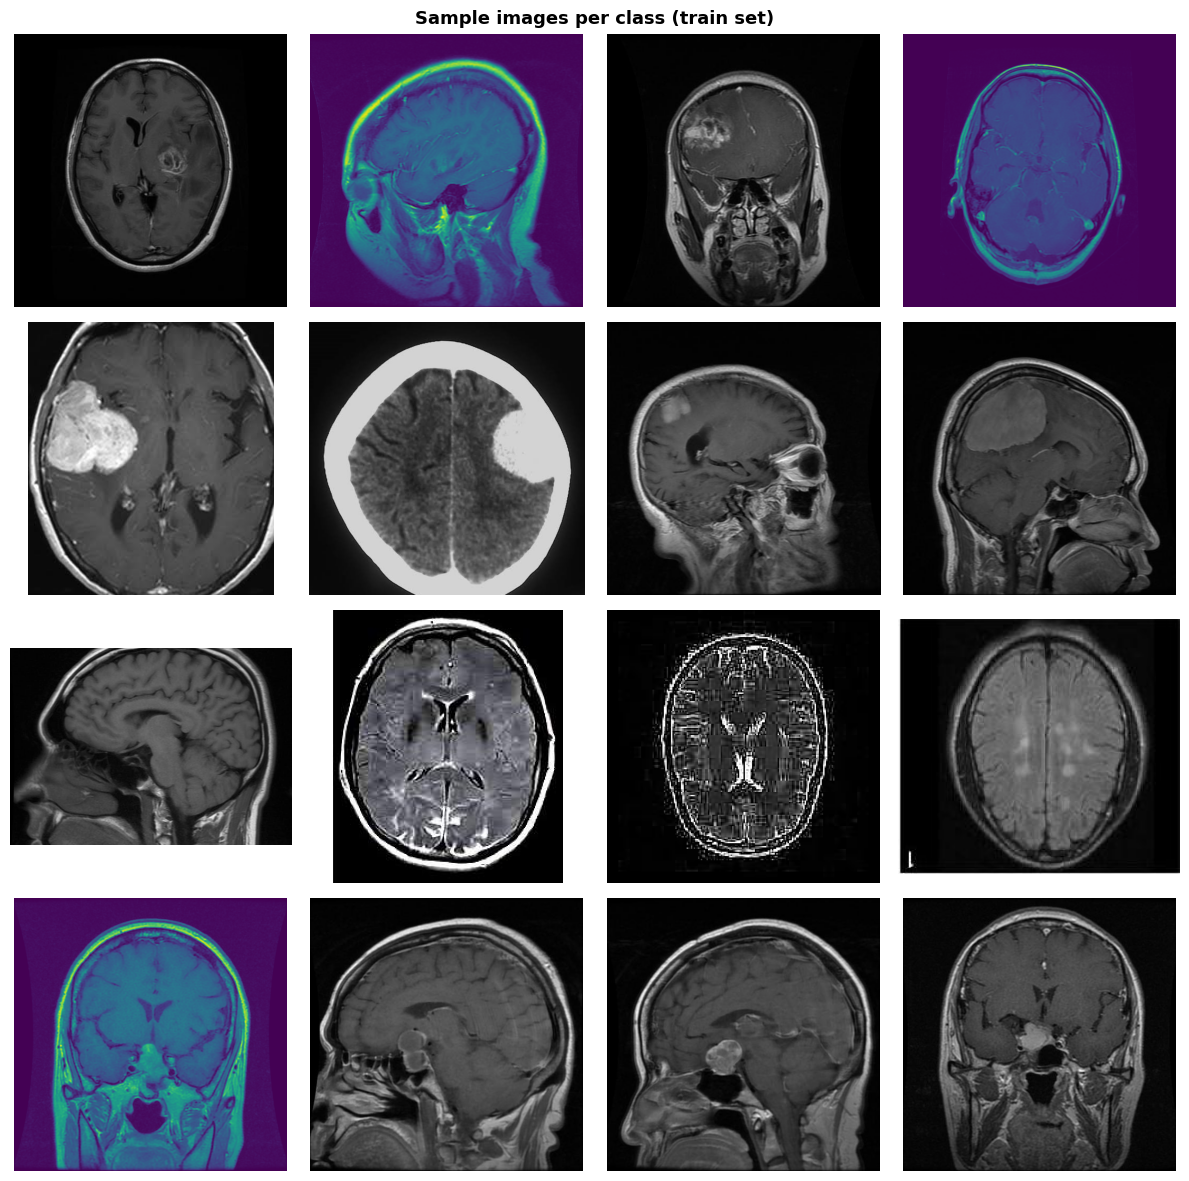

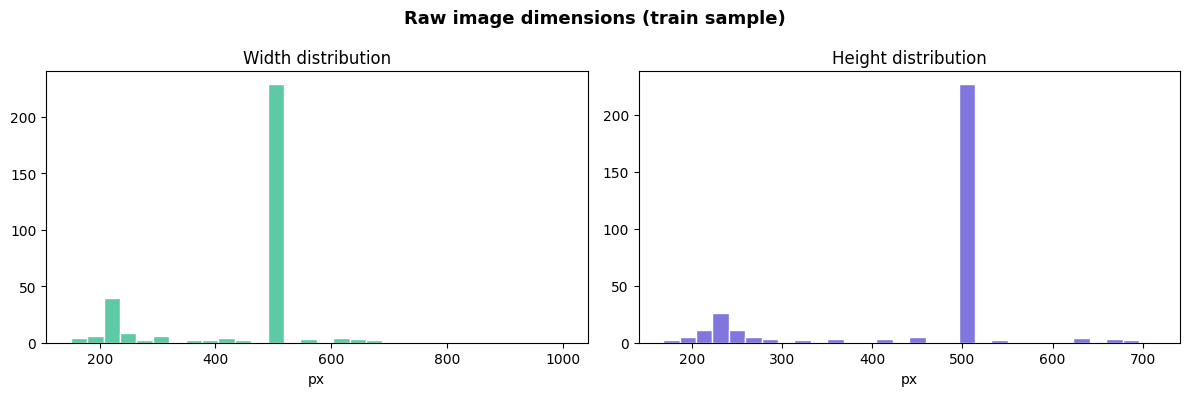

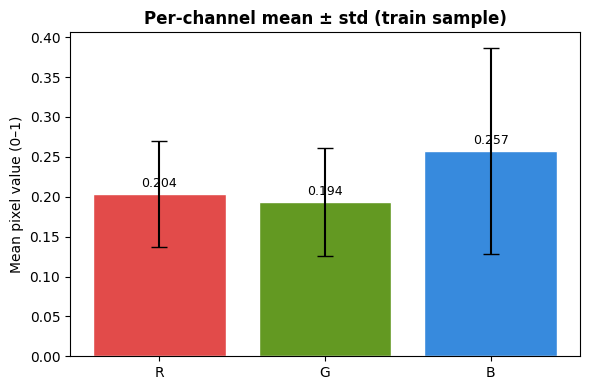


Dataset summary
────────────────────────────────────
  train: 7390 images  {'glioma': 2627, 'meningioma': 1640, 'no_tumor': 1229, 'pituitary': 1894}
  val  : 2110 images  {'glioma': 750, 'meningioma': 468, 'no_tumor': 351, 'pituitary': 541}
  test : 1060 images  {'glioma': 377, 'meningioma': 235, 'no_tumor': 177, 'pituitary': 271}


In [5]:
# Class distribution
split_counts = {}
for split in ["train", "val", "test"]:
    split_path = os.path.join(SPLIT_PATH, split)
    counts = {cls: len(os.listdir(os.path.join(split_path, cls)))
              for cls in CLASS_NAMES}
    split_counts[split] = counts

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ["#5DCAA5", "#7F77DD", "#EF9F27"]
for ax, (split, counts), color in zip(axes, split_counts.items(), colors):
    ax.bar(counts.keys(), counts.values(), color=color, edgecolor="white")
    ax.set_title(f"{split.capitalize()} set")
    ax.set_ylabel("Images")
    ax.tick_params(axis="x", rotation=20)
    for i, v in enumerate(counts.values()):
        ax.text(i, v + 1, str(v), ha="center", fontsize=9)
plt.suptitle("Class distribution per split", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Sample images per class 
train_path = os.path.join(SPLIT_PATH, "train")
n_cols = 4
fig, axes = plt.subplots(len(CLASS_NAMES), n_cols, figsize=(n_cols * 3, len(CLASS_NAMES) * 3))

for row, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(train_path, cls)
    files = os.listdir(cls_path)
    samples = random.sample(files, min(n_cols, len(files)))
    for col, fname in enumerate(samples):
        img = Image.open(os.path.join(cls_path, fname)).convert("RGB")
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(cls, fontsize=11, fontweight="bold", rotation=0,
                                      labelpad=60, va="center")

plt.suptitle("Sample images per class (train set)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Image size distribution
widths, heights = [], []
for cls in CLASS_NAMES:
    cls_path = os.path.join(train_path, cls)
    for fname in os.listdir(cls_path)[:80]:   # sample 80 per class
        try:
            w, h = Image.open(os.path.join(cls_path, fname)).size
            widths.append(w)
            heights.append(h)
        except Exception:
            pass

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(widths,  bins=30, color="#5DCAA5", edgecolor="white")
ax1.set_title("Width distribution");  ax1.set_xlabel("px")
ax2.hist(heights, bins=30, color="#7F77DD", edgecolor="white")
ax2.set_title("Height distribution"); ax2.set_xlabel("px")
plt.suptitle("Raw image dimensions (train sample)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Per channel mean and std
import numpy as np

r_vals, g_vals, b_vals = [], [], []
for cls in CLASS_NAMES:
    cls_path = os.path.join(train_path, cls)
    for fname in os.listdir(cls_path)[:50]:
        try:
            arr = np.array(Image.open(os.path.join(cls_path, fname)).convert("RGB")) / 255.0
            r_vals.append(arr[:, :, 0].mean())
            g_vals.append(arr[:, :, 1].mean())
            b_vals.append(arr[:, :, 2].mean())
        except Exception:
            pass

channels = ["R", "G", "B"]
means  = [np.mean(r_vals), np.mean(g_vals), np.mean(b_vals)]
stds   = [np.std(r_vals),  np.std(g_vals),  np.std(b_vals)]
ch_colors = ["#E24B4A", "#639922", "#378ADD"]

fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(3)
bars = ax.bar(x, means, yerr=stds, color=ch_colors, capsize=6, edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(channels)
ax.set_ylabel("Mean pixel value (0–1)")
ax.set_title("Per-channel mean ± std (train sample)", fontweight="bold")
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, m + 0.005, f"{m:.3f}",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

print("\nDataset summary")
print("─" * 36)
for split, counts in split_counts.items():
    total = sum(counts.values())
    print(f"  {split:5s}: {total:4d} images  {dict(counts)}")

## 6. Data Loaders

In [6]:
def get_dataloaders(split_path, train_transform, eval_transform, batch_size=BATCH_SIZE):
    train_dataset = datasets.ImageFolder(os.path.join(split_path, "train"), transform=train_transform)
    val_dataset   = datasets.ImageFolder(os.path.join(split_path, "val"),   transform=eval_transform)

    train_loader = torch.utils.data.DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True,
        num_workers=4, persistent_workers=True, pin_memory=True, prefetch_factor=2
    )
    val_loader = torch.utils.data.DataLoader(
        val_dataset, batch_size=batch_size, shuffle=False,
        num_workers=2, persistent_workers=True, pin_memory=True, prefetch_factor=2
    )
    return train_loader, val_loader


def get_test_loader(split_path, eval_transform, batch_size=BATCH_SIZE):
    test_dataset = datasets.ImageFolder(os.path.join(split_path, "test"), transform=eval_transform)
    test_loader  = torch.utils.data.DataLoader(
        test_dataset, batch_size=batch_size, shuffle=False,
        num_workers=2, persistent_workers=True, pin_memory=True, prefetch_factor=2
    )
    return test_loader, test_dataset

## 7. Model

In [7]:
class TumorClassifier(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, x):
        return self.model(x)

## 8. Evaluation Helper

In [8]:
def evaluate(model, dataloader, device):
    model.eval()
    all_labels, all_preds = [], []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    cm  = confusion_matrix(all_labels, all_preds)
    return acc, cm, all_labels, all_preds

## 9. Training

In [9]:
def train():
    train_transform = get_train_transform()
    eval_transform  = get_eval_transform()

    train_loader, val_loader = get_dataloaders(SPLIT_PATH, train_transform, eval_transform)

    model = TumorClassifier(num_classes=NUM_CLASSES).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()), lr=LR
    )

    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch {epoch+1}/{NUM_EPOCHS}  Loss: {running_loss / len(train_loader):.4f}")

        val_acc, _, _, _ = evaluate(model, val_loader, device)
        print(f"  Val accuracy: {val_acc:.4f}")

    os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
    torch.save(model.state_dict(), MODEL_PATH)
    print("Model saved to", MODEL_PATH)
    return model

model = train()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 37.5MB/s]


Epoch 1/20  Loss: 0.5300
  Val accuracy: 0.9232
Epoch 2/20  Loss: 0.3402
  Val accuracy: 0.8616
Epoch 3/20  Loss: 0.2992
  Val accuracy: 0.9152
Epoch 4/20  Loss: 0.2660
  Val accuracy: 0.9237
Epoch 5/20  Loss: 0.2508
  Val accuracy: 0.9209
Epoch 6/20  Loss: 0.2310
  Val accuracy: 0.9284
Epoch 7/20  Loss: 0.2044
  Val accuracy: 0.9275
Epoch 8/20  Loss: 0.2187
  Val accuracy: 0.9204
Epoch 9/20  Loss: 0.1883
  Val accuracy: 0.9327
Epoch 10/20  Loss: 0.2013
  Val accuracy: 0.9687
Epoch 11/20  Loss: 0.1739
  Val accuracy: 0.9730
Epoch 12/20  Loss: 0.1774
  Val accuracy: 0.9654
Epoch 13/20  Loss: 0.1610
  Val accuracy: 0.9493
Epoch 14/20  Loss: 0.1615
  Val accuracy: 0.9678
Epoch 15/20  Loss: 0.1469
  Val accuracy: 0.9706
Epoch 16/20  Loss: 0.1464
  Val accuracy: 0.9668
Epoch 17/20  Loss: 0.1460
  Val accuracy: 0.9697
Epoch 18/20  Loss: 0.1444
  Val accuracy: 0.9502
Epoch 19/20  Loss: 0.1417
  Val accuracy: 0.9768
Epoch 20/20  Loss: 0.1400
  Val accuracy: 0.9711
Model saved to /workspaces/br

## 10. Testing

In [10]:
def load_model(device):
    m = TumorClassifier(num_classes=NUM_CLASSES).to(device)
    m.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    m.eval()
    return m

def test():
    eval_transform = get_eval_transform()
    test_loader, test_dataset = get_test_loader(SPLIT_PATH, eval_transform)

    m = load_model(device)
    acc, cm, _, _ = evaluate(m, test_loader, device)

    print("Testing samples:", len(test_dataset))
    print(f"Test accuracy:   {acc:.4f}")

    df_cm = pd.DataFrame(cm, index=test_dataset.classes, columns=test_dataset.classes)
    print(df_cm)

test()

Testing samples: 1060
Test accuracy:   0.9594
            glioma  meningioma  no_tumor  pituitary
glioma         347          25         4          1
meningioma       0         233         1          1
no_tumor         1           1       175          0
pituitary        0           9         0        262


## 11. Grad-CAM

In [11]:
class GradCAM:
    def __init__(self, model):
        self.model = model
        self.gradients = None
        self.activations = None

        target_layer = self.model.model.layer4
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, x):
        output = self.model(x)
        pred_class = output.argmax(dim=1)

        self.model.zero_grad()
        output[0, pred_class].backward()

        grads       = self.gradients[0]
        activations = self.activations[0]
        weights     = grads.mean(dim=(1, 2))

        cam = torch.zeros(activations.shape[1:], device=x.device)
        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = F.relu(cam)
        cam -= cam.min()
        if cam.max() != 0:
            cam /= cam.max()

        return cam.detach().cpu(), pred_class.item()


def overlay_heatmap(cam, image):
    image   = np.array(image).astype(np.uint8)
    cam_np  = cv2.resize(cam.numpy(), (image.shape[1], image.shape[0]))
    cam_np  = np.uint8(255 * cam_np)
    heatmap = cv2.applyColorMap(cam_np, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(heatmap, 0.5, image, 0.5, 0)


def apply_augmentation(image, choice):
    if choice == "Blur":
        image = image.filter(ImageFilter.GaussianBlur(radius=5))
    elif choice == "Black box":
        img_np = np.array(image)
        h, w, _ = img_np.shape
        img_np[h//3:2*h//3, w//3:2*w//3] = 0
        image = Image.fromarray(img_np)
    elif choice == "Noise":
        img_np = np.array(image).astype(np.float32)
        noise  = np.random.normal(0, 25, img_np.shape)
        img_np = np.clip(img_np + noise, 0, 255).astype(np.uint8)
        image  = Image.fromarray(img_np)
    return image


def run_gradcam(model, gradcam_obj, image, device, class_names, augmentation="None"):
    image = apply_augmentation(image, augmentation)

    eval_transform    = get_eval_transform()
    display_transform = get_display_transform()

    input_tensor  = eval_transform(image).unsqueeze(0).to(device)
    display_image = display_transform(image)

    cam, pred = gradcam_obj.generate(input_tensor)
    overlay   = overlay_heatmap(cam, display_image)

    return overlay, display_image, class_names[pred]

## 12. Gradio App

In [12]:
app_model   = load_model(device)
gradcam_obj = GradCAM(app_model)

def predict(image, aug):
    overlay, display, pred = run_gradcam(
        app_model, gradcam_obj, image, device, CLASS_NAMES, aug
    )
    return overlay, pred

demo = gr.Interface(
    fn=predict,
    inputs=[
        gr.Image(type="pil"),
        gr.Dropdown(["None", "Blur", "Black box", "Noise"])
    ],
    outputs=[
        gr.Image(label="Grad-CAM"),
        gr.Text(label="Prediction")
    ],
    title="Brain Tumor Grad-CAM"
)

demo.launch(server_name="0.0.0.0", server_port=7860)

* Running on local URL:  http://0.0.0.0:7860
* To create a public link, set `share=True` in `launch()`.
